# Strategy comparison — walk-forward GMM (K=4 vs K=5)

Monthly backtest from **1990**, **$10,000** contributed each month.
Signals lagged 1 month (no look-ahead). Transaction costs: **5 bps** on turnover.

| ID | Strategy |
|----|----------|
| B0 | Buy & hold SPXT |
| 1 | Risk-on / risk-off (hard + soft) |
| 2 | Safe haven rotation (hard + soft) |
| 3 | All-weather macro (hard + soft) |
| 4 | Inverse vol scaling (hard + soft) |
| 5 | Defensive safe haven (hard + soft) |
| 6 | Crisis-cap inverse vol (hard + soft) |
| 7 | Bond floor tactical (hard + soft) |
| 8 | All-weather defensive (hard + soft) |
| 9 | Convex soft risk-on (hard + soft) |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def _find_pmr_root() -> Path:
    start = Path.cwd().resolve()
    for parent in [start, *start.parents]:
        if (parent / "scripts" / "paths.py").is_file():
            return parent
    raise FileNotFoundError("Run from inside pmr_paper/")

PROJECT_ROOT = _find_pmr_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.backtest.engine import (
    DEFAULT_MONTHLY_CONTRIBUTION,
    run_strategy_comparison_cell,
)
from scripts.backtest.loaders import load_backtest_panel
from scripts.backtest.signals import load_walk_forward_signals

MONTHLY_CONTRIBUTION = DEFAULT_MONTHLY_CONTRIBUTION
returns_panel = load_backtest_panel()
signals_k4 = load_walk_forward_signals(4)
signals_k5 = load_walk_forward_signals(5)

print(f"Backtest months: {len(returns_panel)} ({returns_panel.index.min().date()} → {returns_panel.index.max().date()})")
print(f"Monthly contribution: ${MONTHLY_CONTRIBUTION:,.0f}")

ALL_METRICS: list[pd.DataFrame] = []

def run_cell(strategy_key: str, *, soft: bool | None = None, title: str | None = None) -> pd.DataFrame:
    """Run strategy for K=4 and K=5, plot USD value + drawdown, print metrics."""
    metrics = run_strategy_comparison_cell(
        strategy_key,
        soft=soft,
        returns_panel=returns_panel,
        signals_k4=signals_k4,
        signals_k5=signals_k5,
        monthly_contribution=MONTHLY_CONTRIBUTION,
        title=title,
    )
    metrics["Strategy"] = strategy_key
    metrics["Mode"] = "soft" if soft else "hard" if soft is not None else "baseline"
    ALL_METRICS.append(metrics)
    plt.show()
    return metrics

Backtest months: 437 (1990-01-31 → 2026-05-31)
Monthly contribution: $10,000


## B0 — Buy & hold SPXT (benchmark)

                  Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                            
K=4 / K=5 (same)     437           4,370,000           50,767,365  46,397,365   11.6172 0.1117      0.1473  0.7586   1.3119       -0.5095  0.2193    0.6613                0.0023


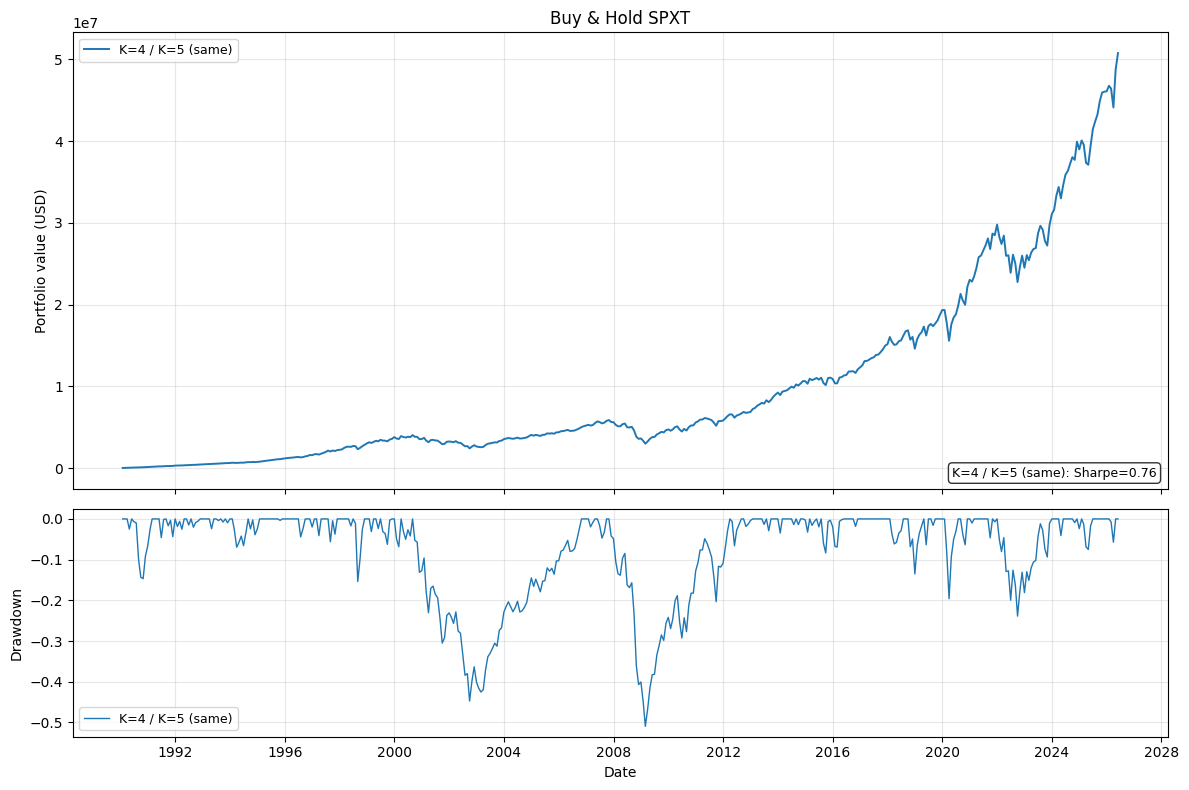

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 / K=5 (same),437,4370000.0,5.076737e+07,4.639737e+07,11.617246,0.111708,0.147263,0.758558,1.311912,-0.509488,0.219255,0.661327,0.002288,73,47.295989,buy_and_hold,baseline


In [2]:
run_cell("buy_and_hold", title="Buy & Hold SPXT")

## 1 — Risk-on / risk-off
Risk-on (Steady / Bull / Inflation) → 100% equity. Risk-off (Crisis / WOI) → cash.

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 hard     437           4,370,000           17,514,153  13,144,153    4.0078 0.0687      0.1188  0.5785   0.9656       -0.4047  0.1699    0.4371                0.2357
K=5 hard     437           4,370,000           42,456,008  38,086,008    9.7153 0.1025      0.1072  0.9559   1.7974       -0.1944  0.5274    0.5126                0.0824


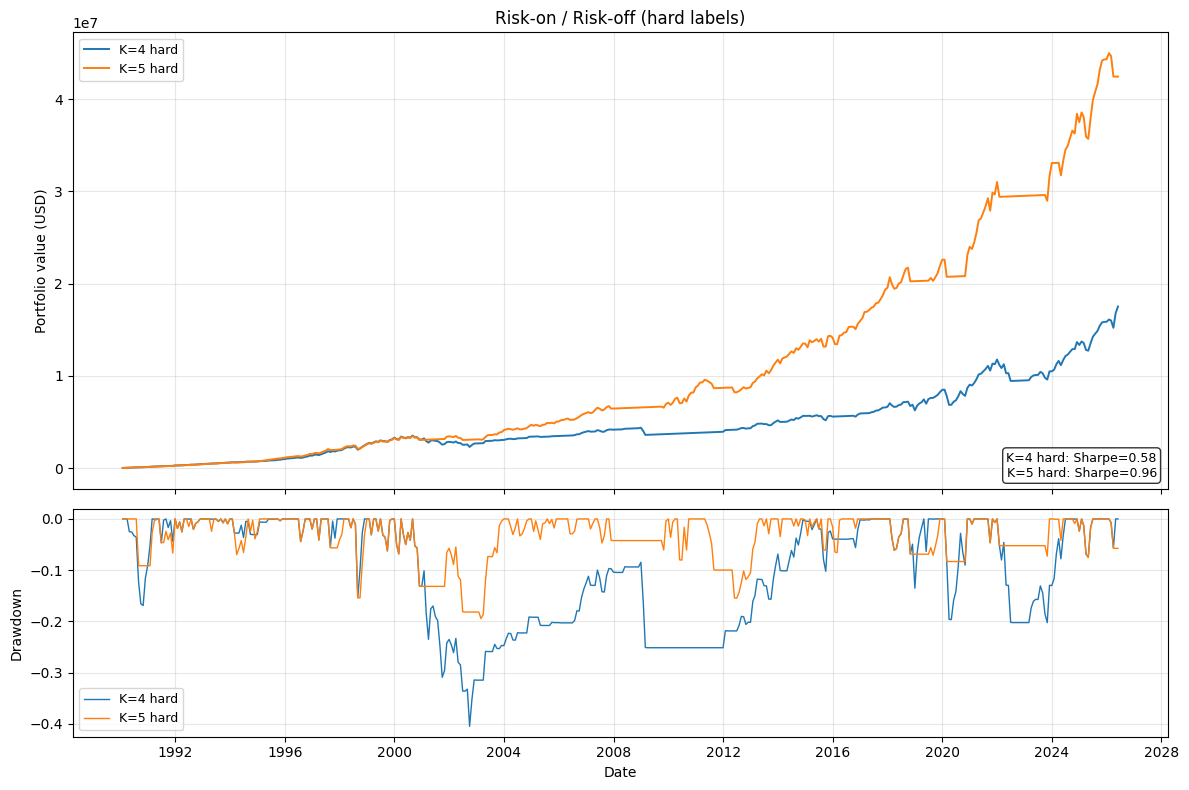

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 hard,437,4370000.0,1.751415e+07,1.314415e+07,4.007815,0.068746,0.118825,0.578543,0.965622,-0.404712,0.169863,0.437071,0.235698,176,11.259166,risk_on_off,hard
K=5 hard,437,4370000.0,4.245601e+07,3.808601e+07,9.715334,0.102514,0.107240,0.955929,1.797354,-0.194381,0.527387,0.512586,0.082380,39,34.953228,risk_on_off,hard


In [3]:
run_cell("risk_on_off", soft=False, title="Risk-on / Risk-off (hard labels)")

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 soft     437           4,370,000           18,634,414  14,264,414    4.2642 0.0712      0.1156  0.6155   1.0289       -0.4086  0.1742    0.6522                0.1944
K=5 soft     437           4,370,000           27,992,474  23,622,474    6.4056 0.0868      0.1090  0.7964   1.3988       -0.3818  0.2274    0.6590                0.1423


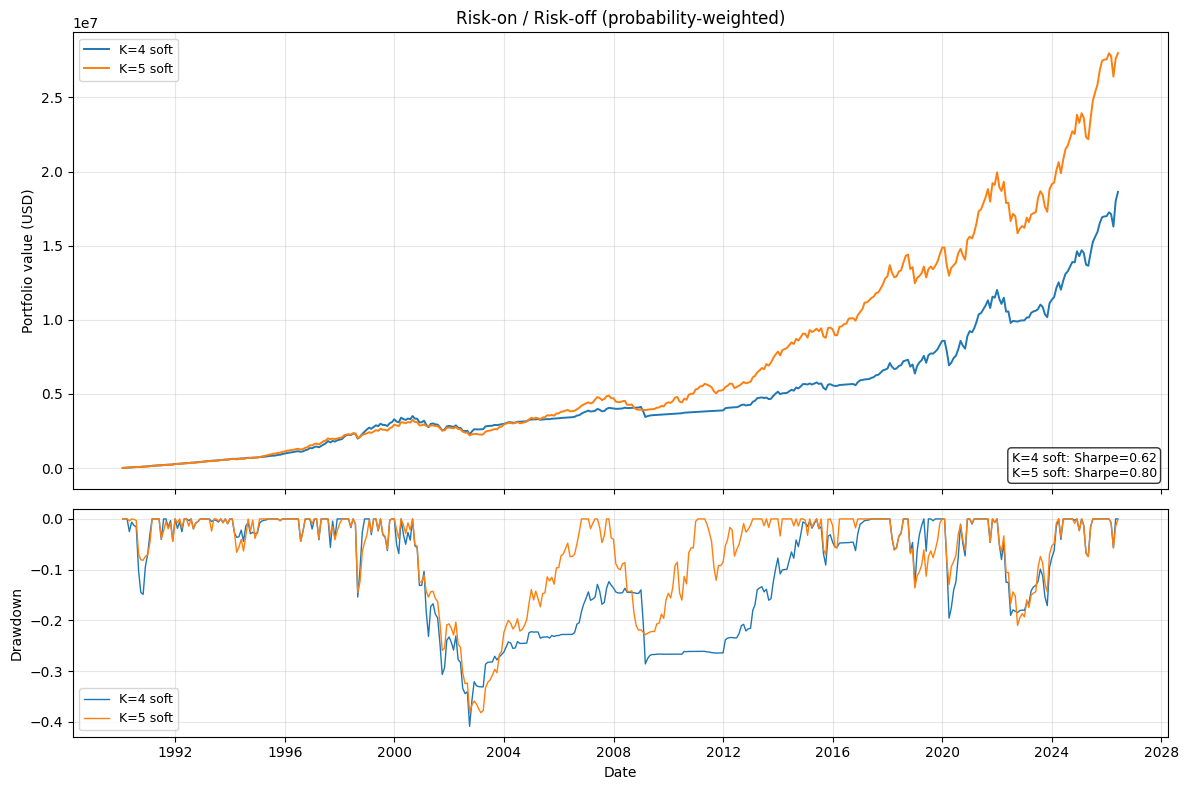

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 soft,437,4370000.0,1.863441e+07,1.426441e+07,4.264168,0.071182,0.115643,0.615536,1.028922,-0.408599,0.174211,0.652174,0.194448,176,12.232783,risk_on_off,soft
K=5 soft,437,4370000.0,2.799247e+07,2.362247e+07,6.405600,0.086808,0.108995,0.796442,1.398775,-0.381789,0.227372,0.659039,0.142300,73,20.728350,risk_on_off,soft


In [4]:
run_cell("risk_on_off", soft=True, title="Risk-on / Risk-off (probability-weighted)")

## 2 — Safe haven rotation
Risk-on → 100% SPXT. Risk-off → 100% LUATTRUU (treasuries).

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 hard     437           4,370,000           25,836,796  21,466,796    5.9123 0.0853      0.1214  0.7027   1.1946       -0.3802  0.2244    0.6362                0.4714
K=5 hard     437           4,370,000           54,450,191  50,080,191   12.4600 0.1157      0.1101  1.0509   2.0008       -0.1860  0.6220    0.6659                0.1648


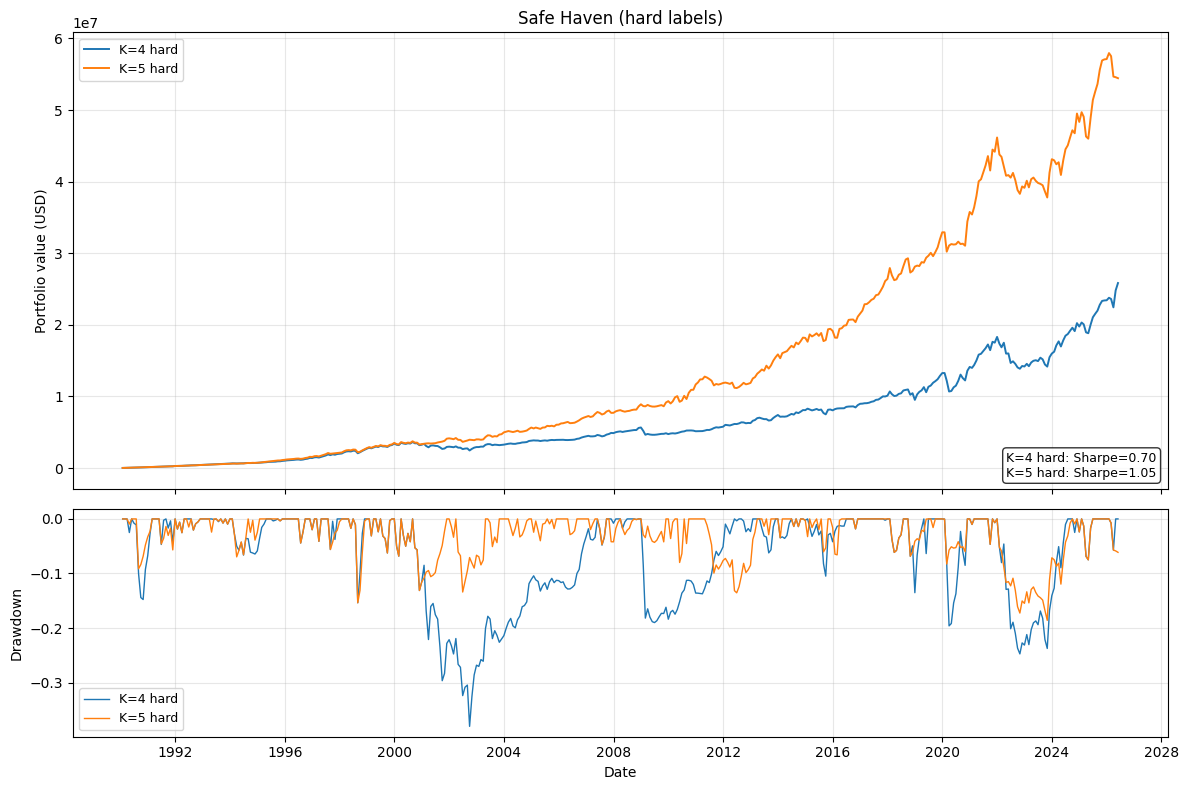

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 hard,437,4370000.0,2.583680e+07,2.146680e+07,5.912310,0.085317,0.121416,0.702688,1.194606,-0.380182,0.224412,0.636156,0.471396,84,19.717773,safe_haven,hard
K=5 hard,437,4370000.0,5.445019e+07,5.008019e+07,12.459998,0.115656,0.110055,1.050900,2.000795,-0.185955,0.621958,0.665904,0.164760,32,53.814711,safe_haven,hard


In [5]:
run_cell("safe_haven", soft=False, title="Safe Haven (hard labels)")

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 soft     437           4,370,000           26,267,366  21,897,366    6.0108 0.0864      0.1181  0.7314   1.2381       -0.3860  0.2239    0.6522                0.3889
K=5 soft     437           4,370,000           34,682,680  30,312,680    7.9365 0.0979      0.1099  0.8903   1.5882       -0.3308  0.2958    0.6636                0.2846


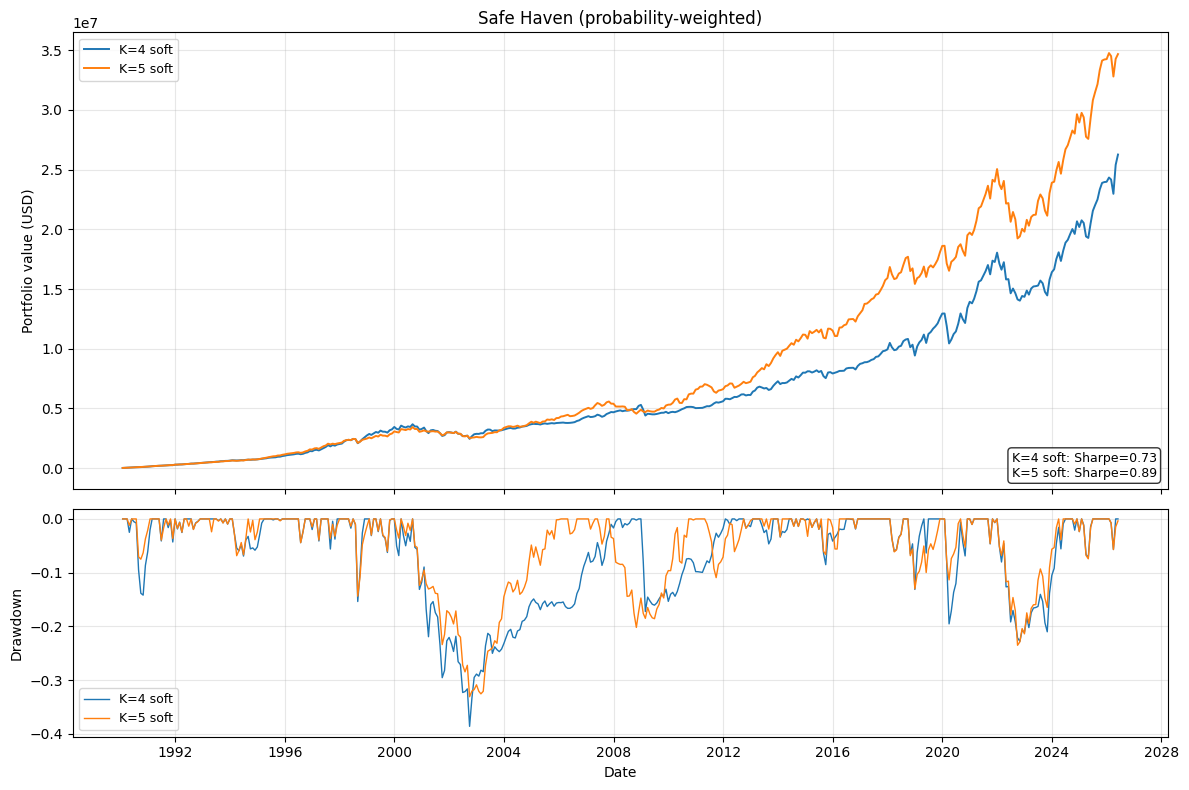

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 soft,437,4370000.0,2.626737e+07,2.189737e+07,6.010839,0.086400,0.118133,0.731378,1.238079,-0.385959,0.223858,0.652174,0.388896,89,20.446974,safe_haven,soft
K=5 soft,437,4370000.0,3.468268e+07,3.031268e+07,7.936540,0.097865,0.109919,0.890341,1.588173,-0.330843,0.295805,0.663616,0.284600,64,29.968151,safe_haven,soft


In [6]:
run_cell("safe_haven", soft=True, title="Safe Haven (probability-weighted)")

## 3 — All-weather macro
Steady/Bull → equity; Crisis/WOI → treasuries; Inflation → commodities (BCOMTR).

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 hard     437           4,370,000           30,151,268  25,781,268    6.8996 0.0952      0.1223  0.7788   1.3690       -0.3802  0.2505    0.6384                0.5332
K=5 hard     437           4,370,000           43,052,773  38,682,773    9.8519 0.1102      0.1112  0.9908   1.8668       -0.2482  0.4440    0.6568                0.1991


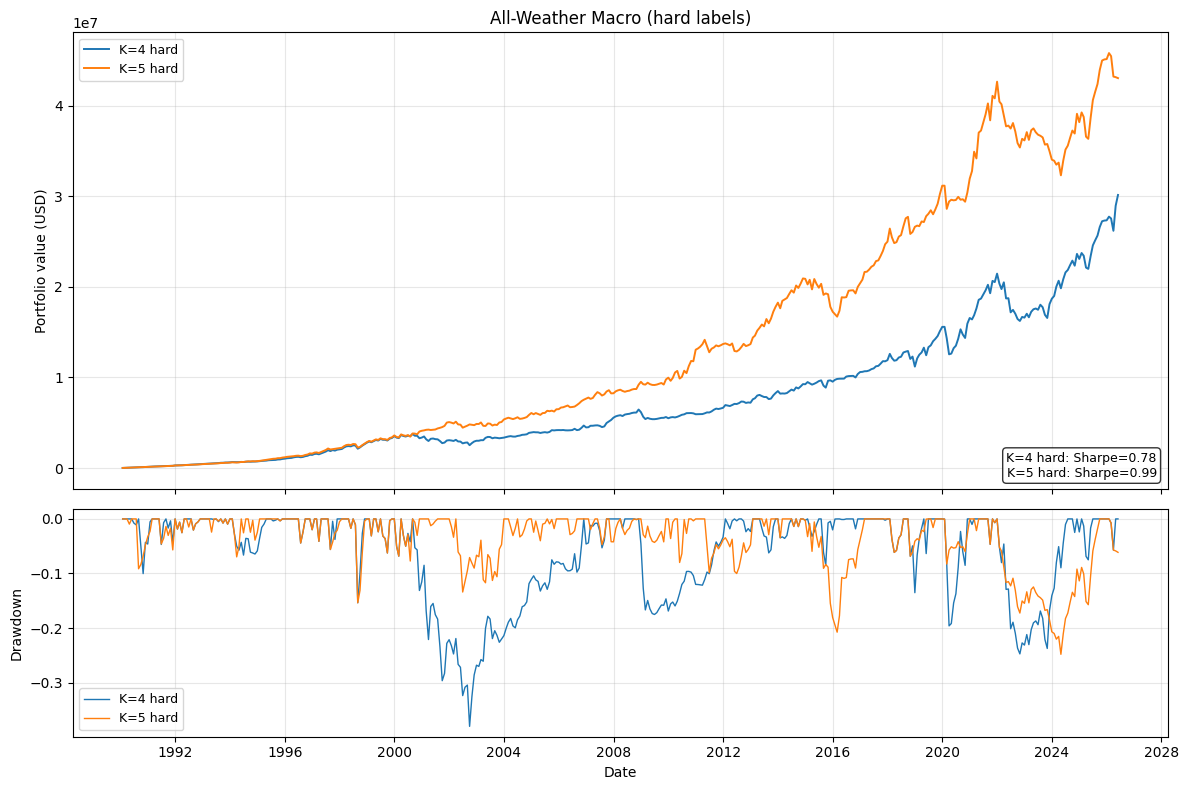

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 hard,437,4370000.0,3.015127e+07,2.578127e+07,6.899604,0.095244,0.122299,0.778780,1.369000,-0.380182,0.250523,0.638444,0.533181,74,27.469989,all_weather,hard
K=5 hard,437,4370000.0,4.305277e+07,3.868277e+07,9.851893,0.110182,0.111207,0.990791,1.866767,-0.248152,0.444012,0.656751,0.199085,44,44.989430,all_weather,hard


In [7]:
run_cell("all_weather", soft=False, title="All-Weather Macro (hard labels)")

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 soft     437           4,370,000           29,595,636  25,225,636    6.7725 0.0936      0.1172  0.7987   1.3898       -0.3860  0.2426    0.6499                0.4396
K=5 soft     437           4,370,000           20,438,670  16,068,670    4.6770 0.0801      0.0982  0.8155   1.4172       -0.2292  0.3495    0.6453                0.5426


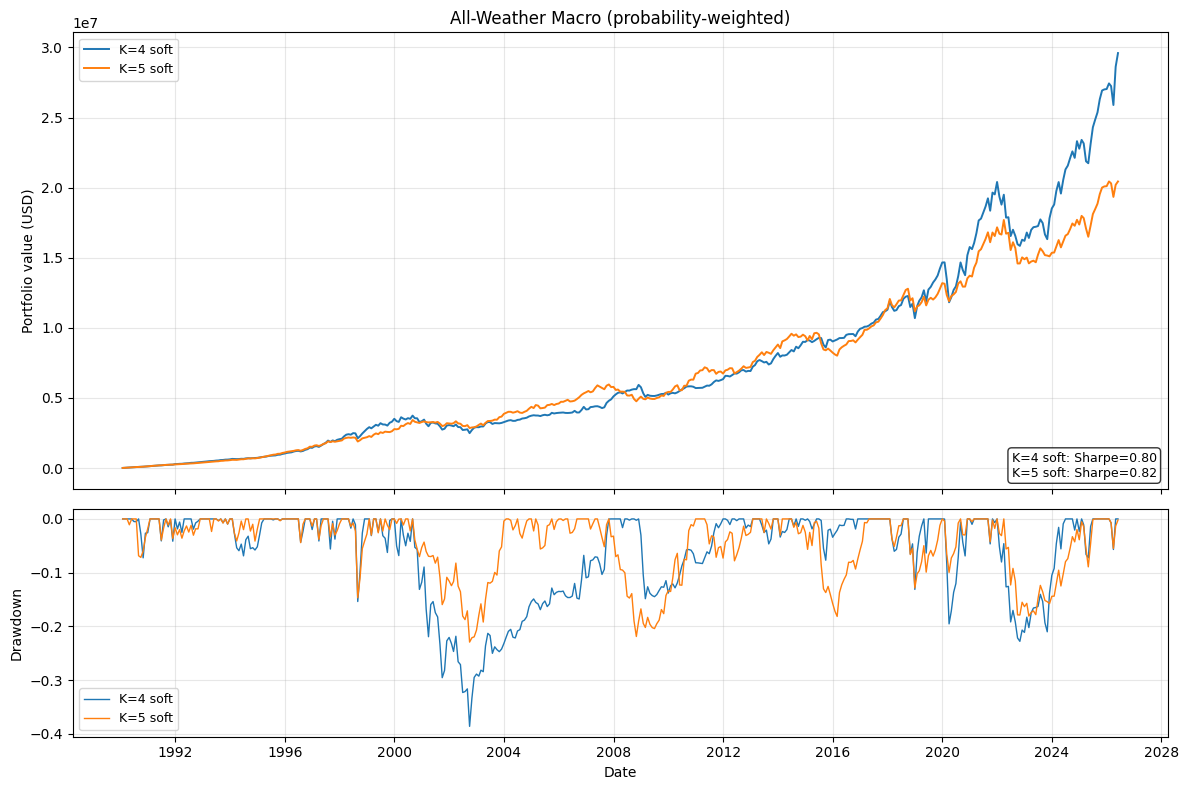

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 soft,437,4370000.0,2.959564e+07,2.522564e+07,6.772457,0.09364,0.117235,0.798741,1.389827,-0.385960,0.242616,0.649886,0.439623,86,26.042145,all_weather,soft
K=5 soft,437,4370000.0,2.043867e+07,1.606867e+07,4.677041,0.08009,0.098207,0.815519,1.417163,-0.229183,0.349458,0.645309,0.542646,40,16.538532,all_weather,soft


In [8]:
run_cell("all_weather", soft=True, title="All-Weather Macro (probability-weighted)")

## 4 — Inverse vol (regime-scaled equity exposure)

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 hard     437           4,370,000           29,887,139  25,517,139    6.8392 0.0905      0.1222  0.7405   1.2818       -0.4260  0.2124    0.6613                0.1510
K=5 hard     437           4,370,000           45,159,309  40,789,309   10.3339 0.1060      0.1068  0.9924   1.8619       -0.2632  0.4027    0.6590                0.0618


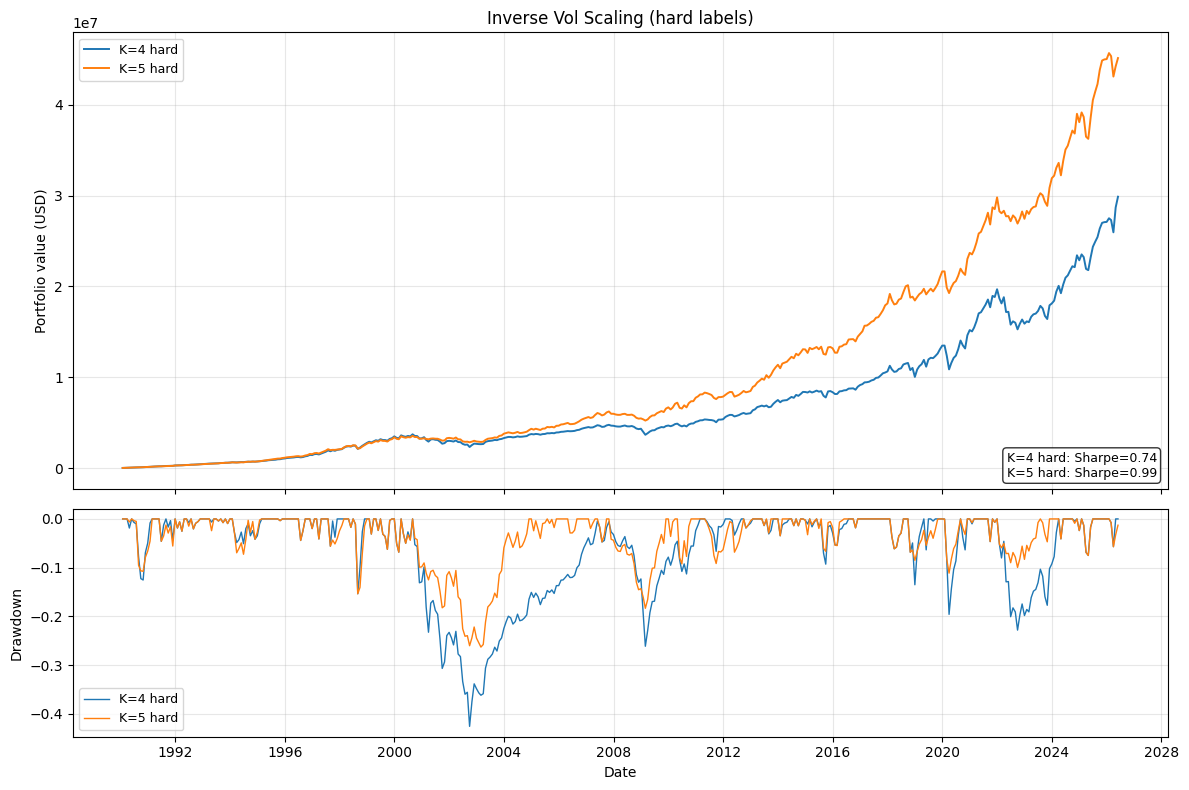

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 hard,437,4370000.0,2.988714e+07,2.551714e+07,6.839162,0.090480,0.122182,0.740532,1.281767,-0.425952,0.212418,0.661327,0.151030,125,23.437309,inverse_vol,hard
K=5 hard,437,4370000.0,4.515931e+07,4.078931e+07,10.333938,0.105991,0.106802,0.992407,1.861940,-0.263182,0.402730,0.659039,0.061785,50,39.200550,inverse_vol,hard


In [9]:
run_cell("inverse_vol", soft=False, title="Inverse Vol Scaling (hard labels)")

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 soft     437           4,370,000           31,418,837  27,048,837    7.1897 0.0921      0.1213  0.7593   1.3200       -0.4280  0.2153    0.6613                0.1197
K=5 soft     437           4,370,000           30,273,993  25,903,993    6.9277 0.0905      0.1114  0.8123   1.4145       -0.3798  0.2384    0.6590                0.1085


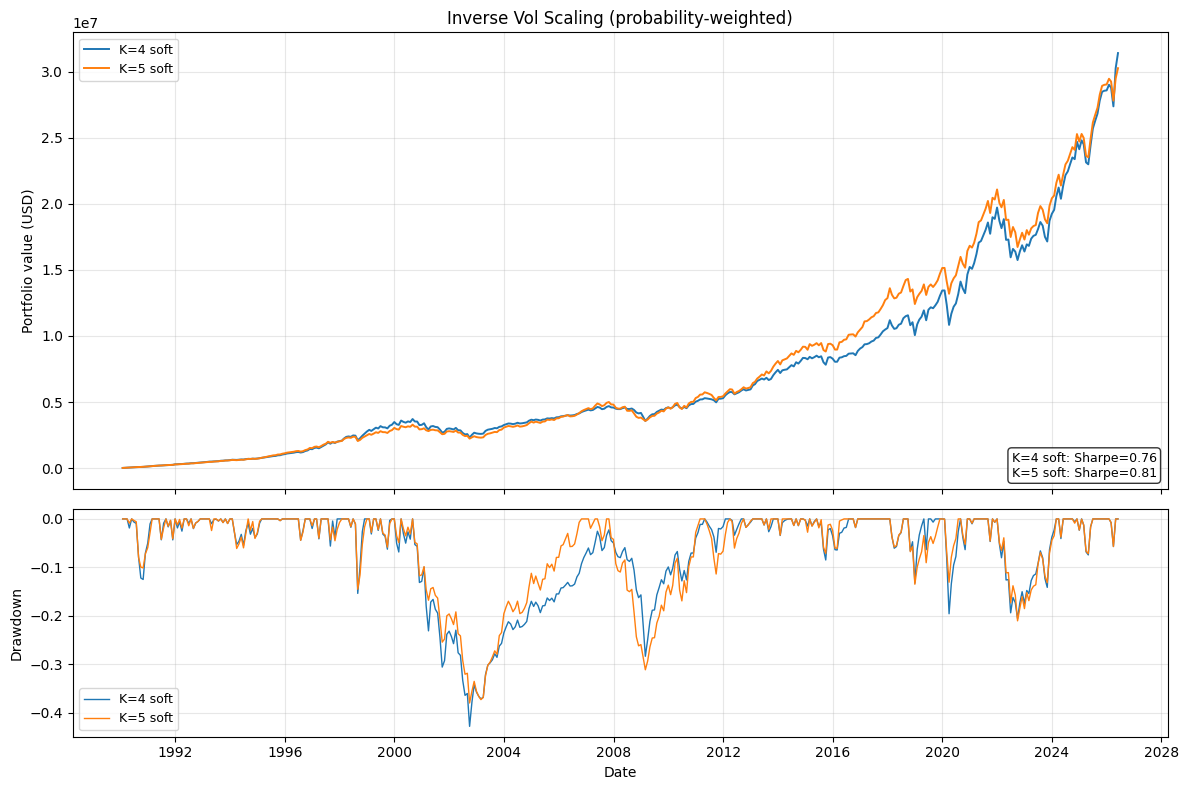

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 soft,437,4370000.0,3.141884e+07,2.704884e+07,7.189665,0.092125,0.121337,0.759250,1.320005,-0.427987,0.215252,0.661327,0.119745,127,24.760078,inverse_vol,soft
K=5 soft,437,4370000.0,3.027399e+07,2.590399e+07,6.927687,0.090523,0.111436,0.812333,1.414547,-0.379791,0.238350,0.659039,0.108465,73,23.471269,inverse_vol,soft


In [10]:
run_cell("inverse_vol", soft=True, title="Inverse Vol Scaling (probability-weighted)")

## 5 — Defensive safe haven
Conservative equity schedule by regime: low equity in inflation, zero in crisis/WOI, high in steady/bull.

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 hard     437           4,370,000           20,208,765  15,838,765    4.6244 0.0771      0.0921  0.8368   1.4937       -0.2540  0.3034    0.6339                0.3462
K=5 hard     437           4,370,000           31,320,124  26,950,124    7.1671 0.0960      0.0890  1.0793   1.9976       -0.1806  0.5319    0.6728                0.1611


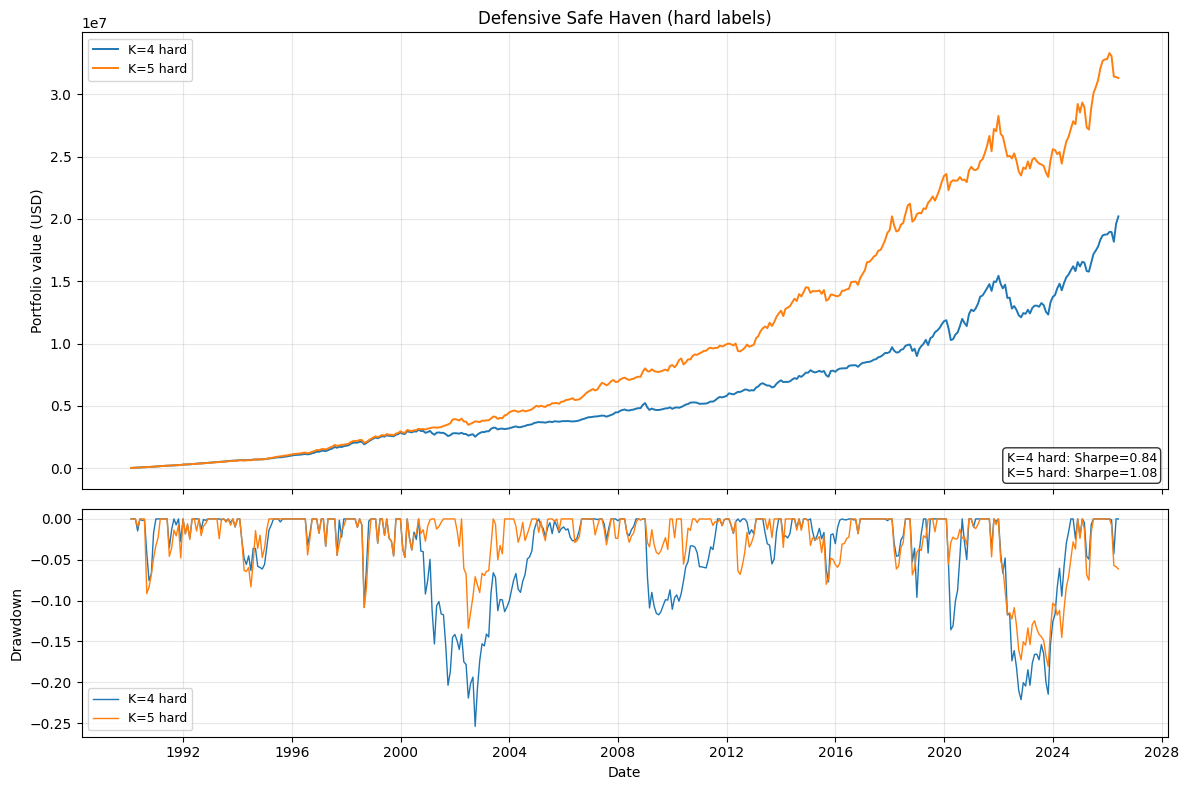

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 hard,437,4370000.0,2.020876e+07,1.583876e+07,4.624431,0.077078,0.092115,0.836759,1.493713,-0.254048,0.303402,0.633867,0.346224,52,14.939657,defensive_safe_haven,hard
K=5 hard,437,4370000.0,3.132012e+07,2.695012e+07,7.167076,0.096041,0.088984,1.079311,1.997565,-0.180575,0.531862,0.672769,0.161098,34,28.207273,defensive_safe_haven,hard


In [11]:
run_cell("defensive_safe_haven", soft=False, title="Defensive Safe Haven (hard labels)")

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 soft     437           4,370,000           20,487,944  16,117,944    4.6883 0.0777      0.0897  0.8667   1.5412       -0.2595  0.2995    0.6522                0.2834
K=5 soft     437           4,370,000           22,198,892  17,828,892    5.0798 0.0813      0.0854  0.9529   1.6515       -0.2069  0.3932    0.6636                0.3685


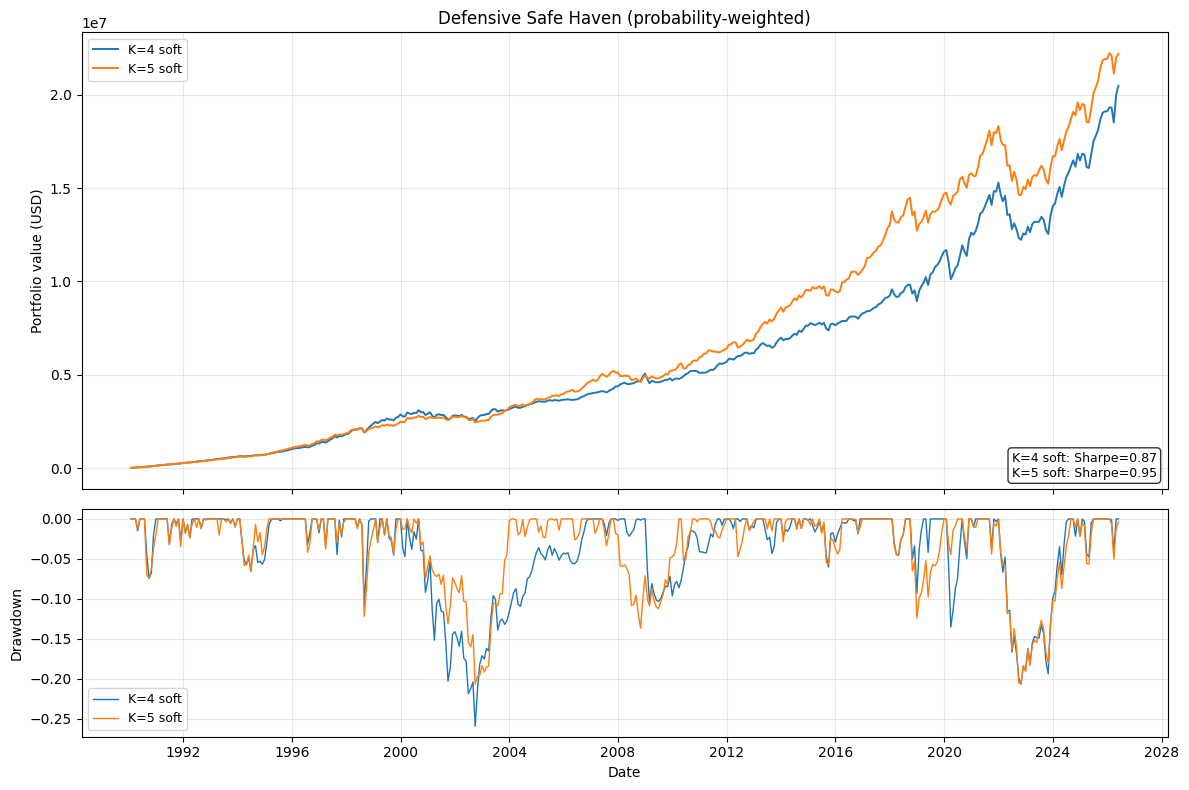

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 soft,437,4370000.0,2.048794e+07,1.611794e+07,4.688317,0.077722,0.089679,0.866668,1.541245,-0.259516,0.299487,0.652174,0.283365,74,15.267986,defensive_safe_haven,soft
K=5 soft,437,4370000.0,2.219889e+07,1.782889e+07,5.079838,0.081345,0.085366,0.952892,1.651456,-0.206872,0.393213,0.663616,0.368474,40,17.252974,defensive_safe_haven,soft


In [12]:
run_cell("defensive_safe_haven", soft=True, title="Defensive Safe Haven (probability-weighted)")

## 6 — Crisis-cap inverse vol
Inverse-vol equity scaling with explicit crisis-probability cap on risk.

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 hard     437           4,370,000           29,862,478  25,492,478    6.8335 0.0903      0.1201  0.7522   1.3001       -0.4260  0.2121    0.6613                0.1673
K=5 hard     437           4,370,000           41,489,015  37,119,015    9.4941 0.1026      0.1036  0.9908   1.8612       -0.2818  0.3643    0.6590                0.0703


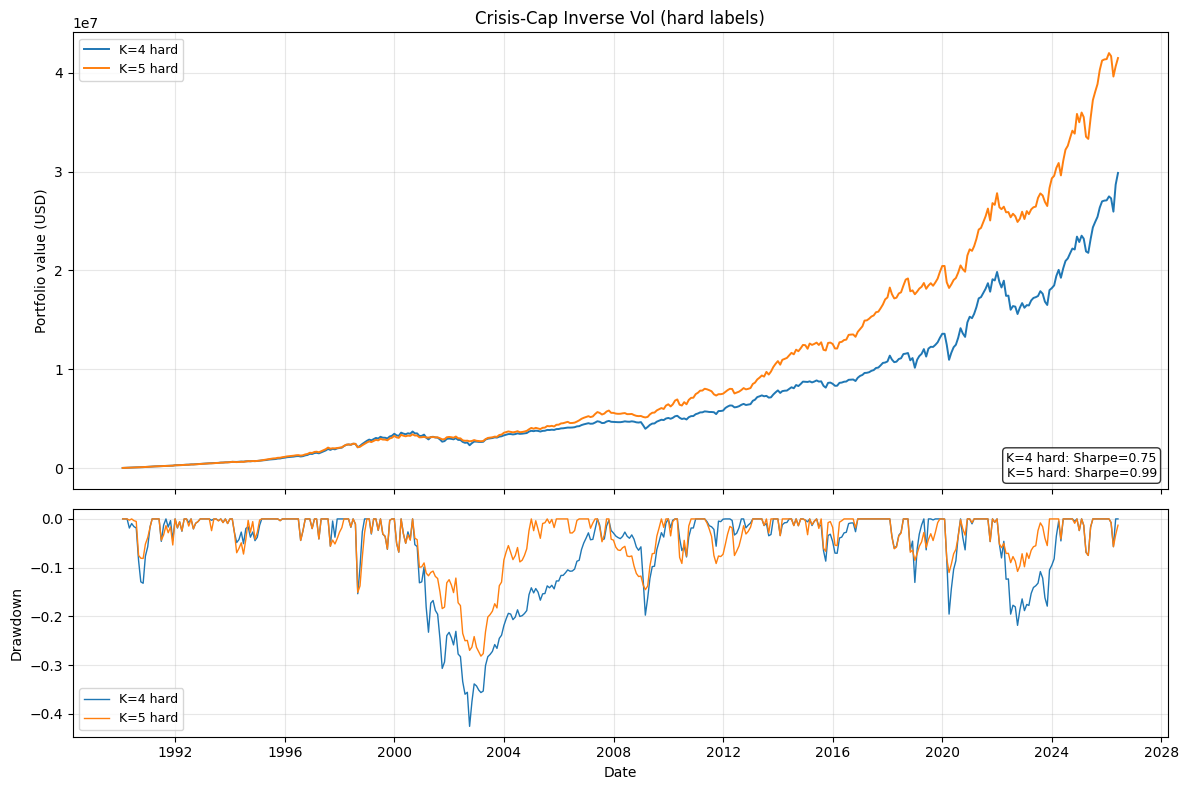

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 hard,437,4370000.0,2.986248e+07,2.549248e+07,6.833519,0.090336,0.120095,0.752203,1.300074,-0.425952,0.212081,0.661327,0.167258,80,23.325097,crisis_cap_inverse_vol,hard
K=5 hard,437,4370000.0,4.148902e+07,3.711902e+07,9.494054,0.102647,0.103600,0.990799,1.861174,-0.281762,0.364303,0.659039,0.070325,51,35.107008,crisis_cap_inverse_vol,hard


In [13]:
run_cell("crisis_cap_inverse_vol", soft=False, title="Crisis-Cap Inverse Vol (hard labels)")

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 soft     437           4,370,000           30,441,562  26,071,562    6.9660 0.0908      0.1197  0.7582   1.3119       -0.4280  0.2121    0.6613                0.1527
K=5 soft     437           4,370,000           27,643,516  23,273,516    6.3257 0.0867      0.1069  0.8106   1.4118       -0.3832  0.2261    0.6590                0.1420


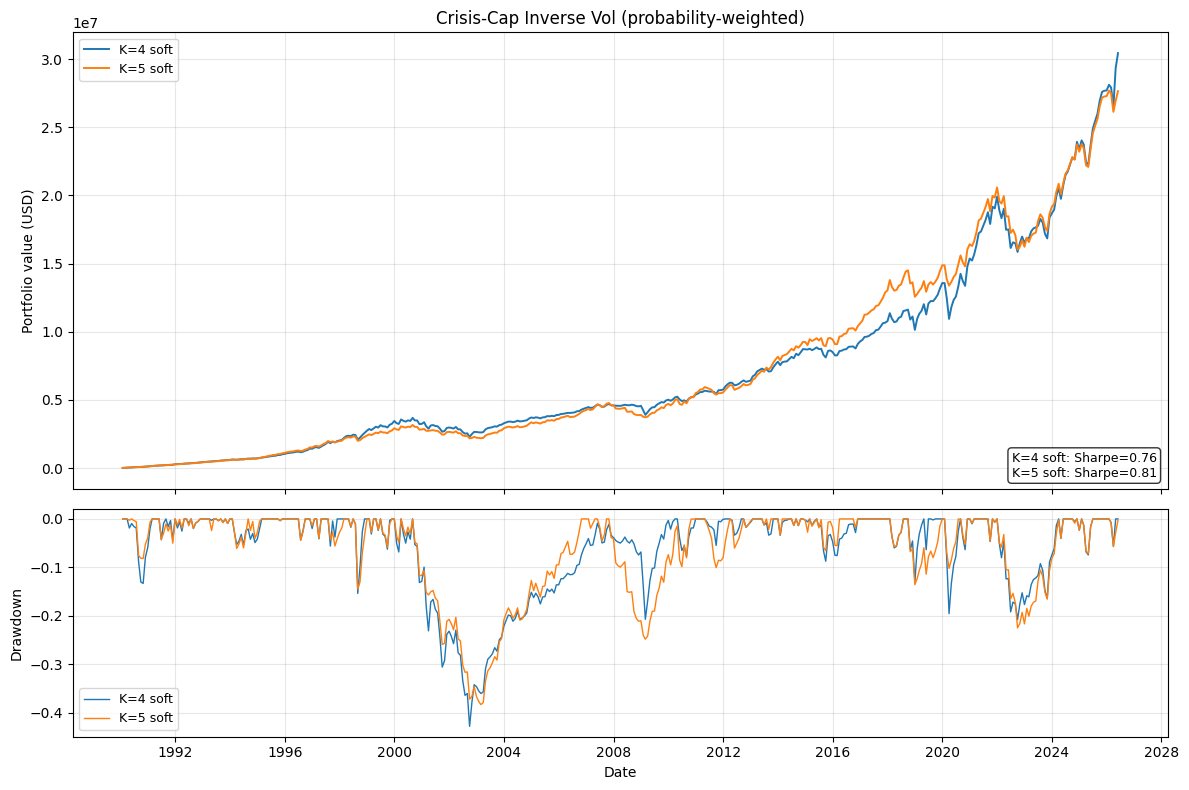

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 soft,437,4370000.0,3.044156e+07,2.607156e+07,6.966033,0.090757,0.119707,0.758157,1.311855,-0.427987,0.212055,0.661327,0.152697,114,23.655040,crisis_cap_inverse_vol,soft
K=5 soft,437,4370000.0,2.764352e+07,2.327352e+07,6.325747,0.086653,0.106897,0.810616,1.411846,-0.383191,0.226134,0.659039,0.141954,73,20.620682,crisis_cap_inverse_vol,soft


In [14]:
run_cell("crisis_cap_inverse_vol", soft=True, title="Crisis-Cap Inverse Vol (probability-weighted)")

## 7 — Bond floor tactical
Two-asset tactical allocation with a permanent treasury floor (30% bond floor).

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 hard     437           4,370,000           19,174,566  14,804,566    4.3878 0.0751      0.0886  0.8483   1.4991       -0.2265  0.3317    0.6407                0.3300
K=5 hard     437           4,370,000           31,384,640  27,014,640    7.1818 0.0958      0.0805  1.1902   2.3563       -0.1747  0.5484    0.6682                0.1153


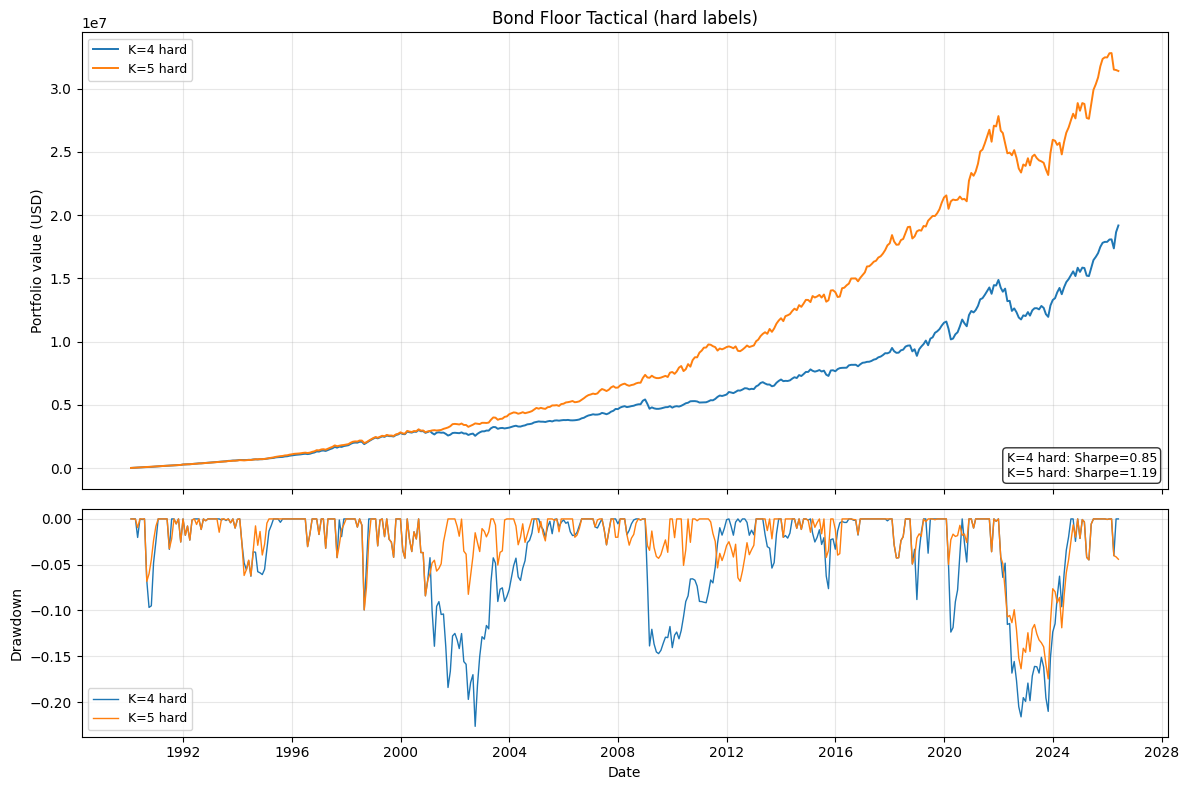

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 hard,437,4370000.0,1.917457e+07,1.480457e+07,4.387773,0.075135,0.088571,0.848298,1.499080,-0.226543,0.331657,0.640732,0.329977,50,13.988568,bond_floor_tactical,hard
K=5 hard,437,4370000.0,3.138464e+07,2.701464e+07,7.181840,0.095826,0.080509,1.190245,2.356277,-0.174749,0.548361,0.668192,0.115332,34,28.006012,bond_floor_tactical,hard


In [15]:
run_cell("bond_floor_tactical", soft=False, title="Bond Floor Tactical (hard labels)")

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 soft     437           4,370,000           19,357,215  14,987,215    4.4296 0.0758      0.0863  0.8787   1.5501       -0.2319  0.3269    0.6545                0.2722
K=5 soft     437           4,370,000           23,365,617  18,995,617    5.3468 0.0836      0.0794  1.0528   1.9572       -0.2040  0.4100    0.6705                0.1992


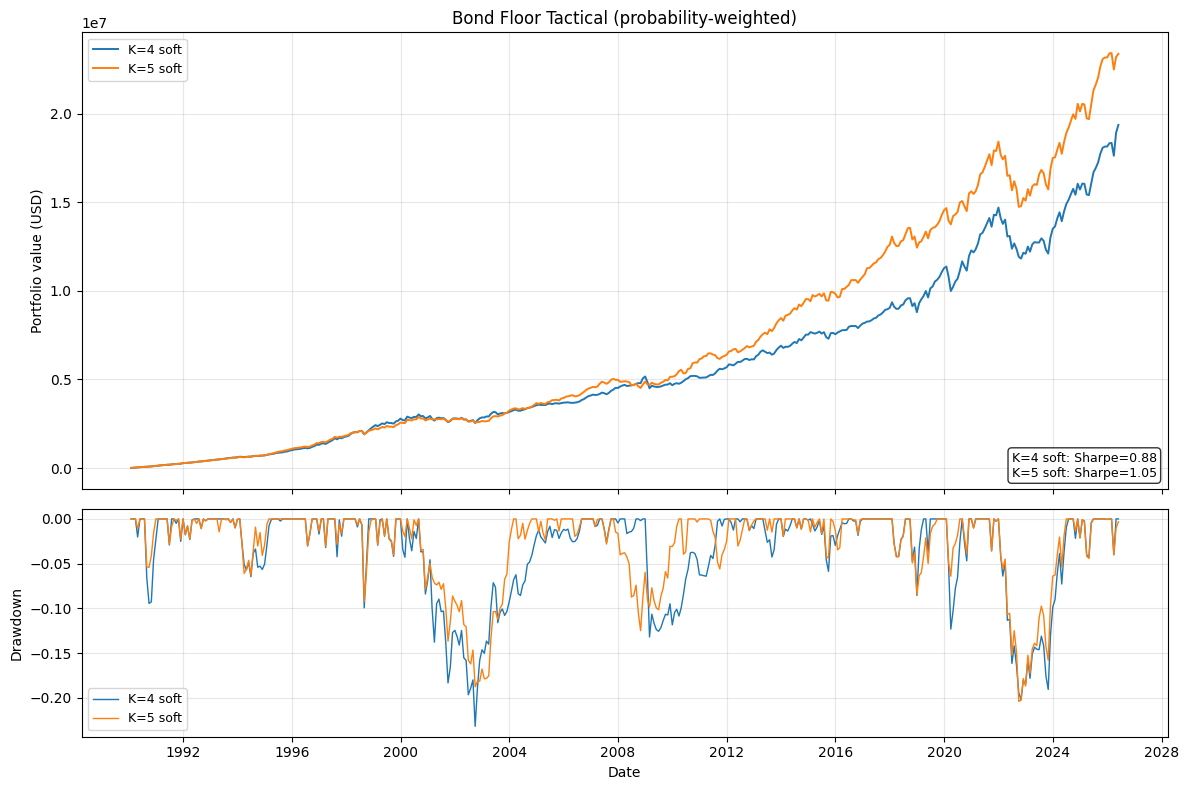

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 soft,437,4370000.0,1.935721e+07,1.498721e+07,4.429569,0.075806,0.086272,0.878687,1.550130,-0.231882,0.326918,0.654462,0.272227,71,14.310310,bond_floor_tactical,soft
K=5 soft,437,4370000.0,2.336562e+07,1.899562e+07,5.346823,0.083640,0.079442,1.052843,1.957177,-0.204025,0.409950,0.670481,0.199220,41,18.638035,bond_floor_tactical,soft


In [16]:
run_cell("bond_floor_tactical", soft=True, title="Bond Floor Tactical (probability-weighted)")

## 8 — All-weather defensive
Diversified three-asset sleeve with floors before regime tilts (equity, treasuries, commodities).

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 hard     437           4,370,000           23,201,983  18,831,983    5.3094 0.0842      0.0896  0.9397   1.6589       -0.2438  0.3452    0.6865                0.2677
K=5 hard     437           4,370,000           27,096,773  22,726,773    6.2006 0.0915      0.0832  1.0998   2.0924       -0.1628  0.5619    0.6705                0.1007


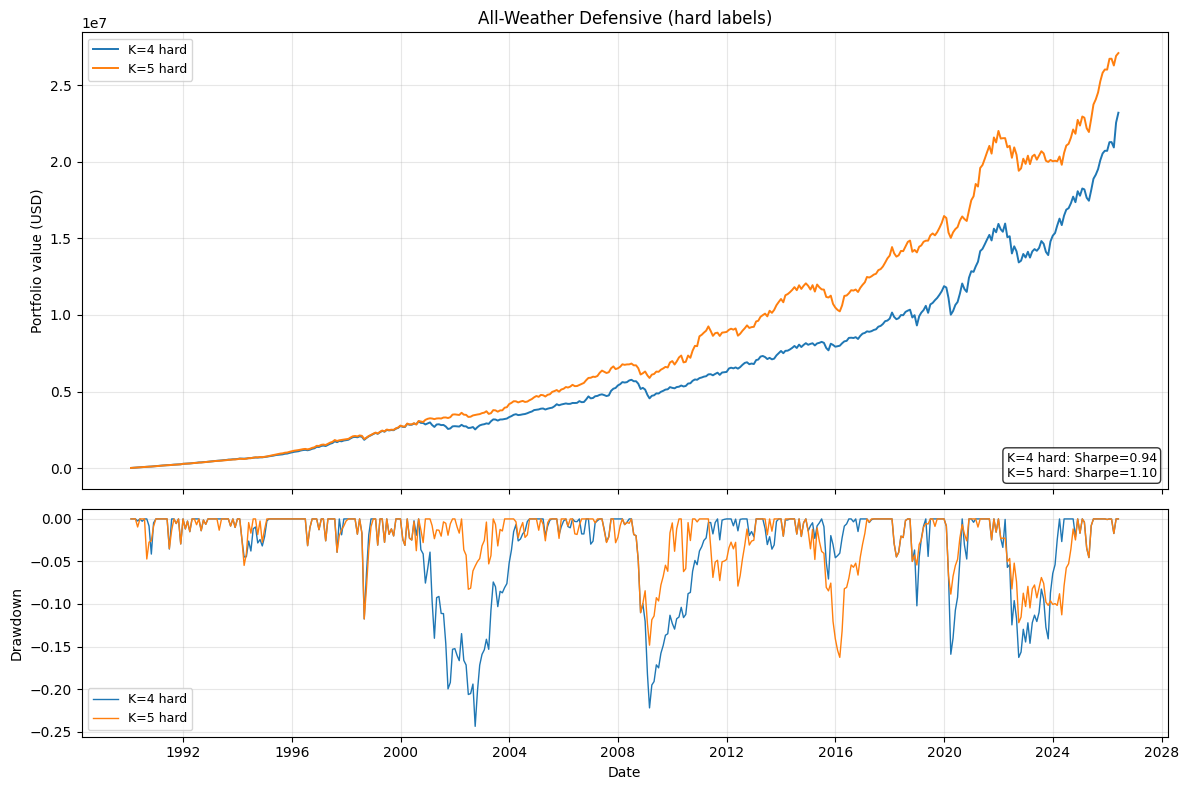

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 hard,437,4370000.0,2.320198e+07,1.883198e+07,5.309378,0.084181,0.089580,0.939725,1.658912,-0.243827,0.345249,0.686499,0.267735,48,18.979731,all_weather_defensive,hard
K=5 hard,437,4370000.0,2.709677e+07,2.272677e+07,6.200635,0.091459,0.083158,1.099829,2.092375,-0.162761,0.561924,0.670481,0.100686,34,24.216221,all_weather_defensive,hard


In [17]:
run_cell("all_weather_defensive", soft=False, title="All-Weather Defensive (hard labels)")

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 soft     437           4,370,000           22,914,585  18,544,585    5.2436 0.0832      0.0881  0.9446   1.6660       -0.2477  0.3359    0.6796                0.2210
K=5 soft     437           4,370,000           18,790,449  14,420,449    4.2999 0.0759      0.0827  0.9172   1.6041       -0.2482  0.3057    0.6499                0.2725


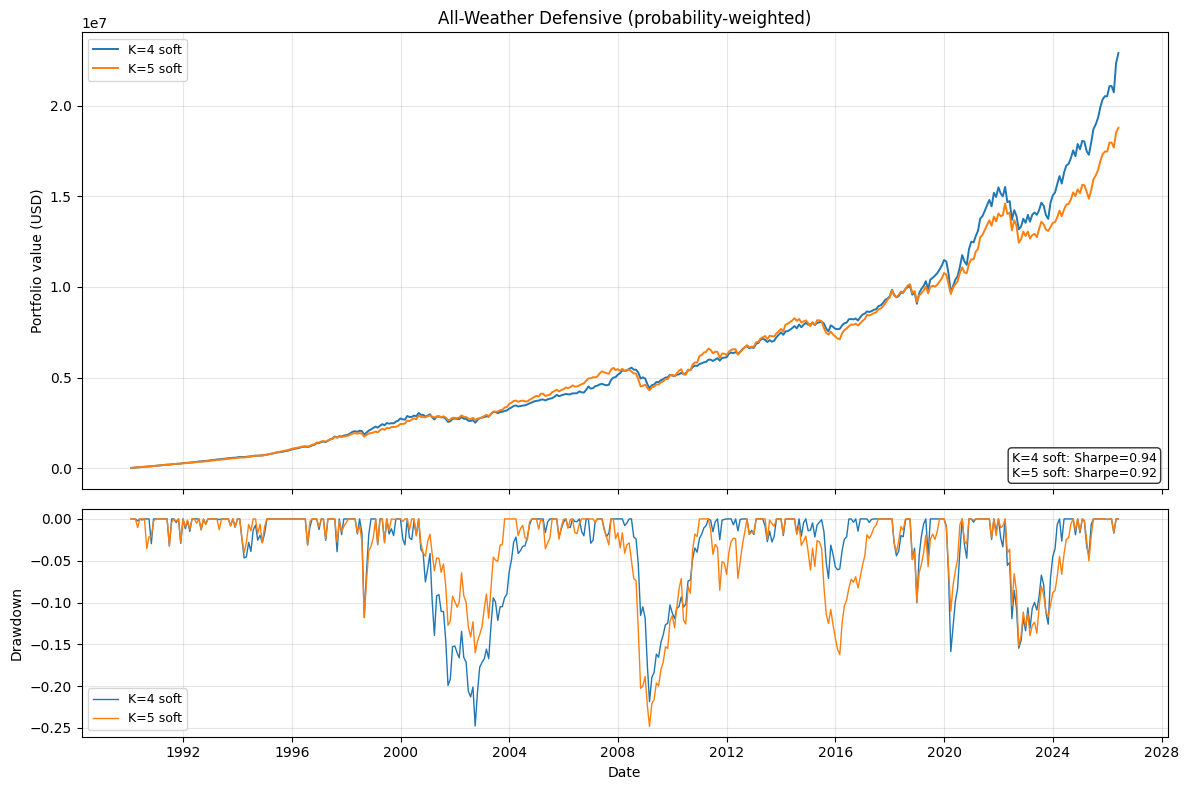

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 soft,437,4370000.0,2.291459e+07,1.854459e+07,5.243612,0.083205,0.088087,0.944580,1.665995,-0.247723,0.335879,0.679634,0.220956,49,18.367396,all_weather_defensive,soft
K=5 soft,437,4370000.0,1.879045e+07,1.442045e+07,4.299874,0.075863,0.082708,0.917241,1.604063,-0.248162,0.305701,0.649886,0.272467,37,14.337963,all_weather_defensive,soft


In [18]:
run_cell("all_weather_defensive", soft=True, title="All-Weather Defensive (probability-weighted)")

## 9 — Convex soft risk-on
Risk-on/off with nonlinear soft mapping: equity = p(risk_on)^gamma (gamma=1.5).

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 hard     437           4,370,000           17,514,153  13,144,153    4.0078 0.0687      0.1188  0.5785   0.9656       -0.4047  0.1699    0.4371                0.2357
K=5 hard     437           4,370,000           42,456,008  38,086,008    9.7153 0.1025      0.1072  0.9559   1.7974       -0.1944  0.5274    0.5126                0.0824


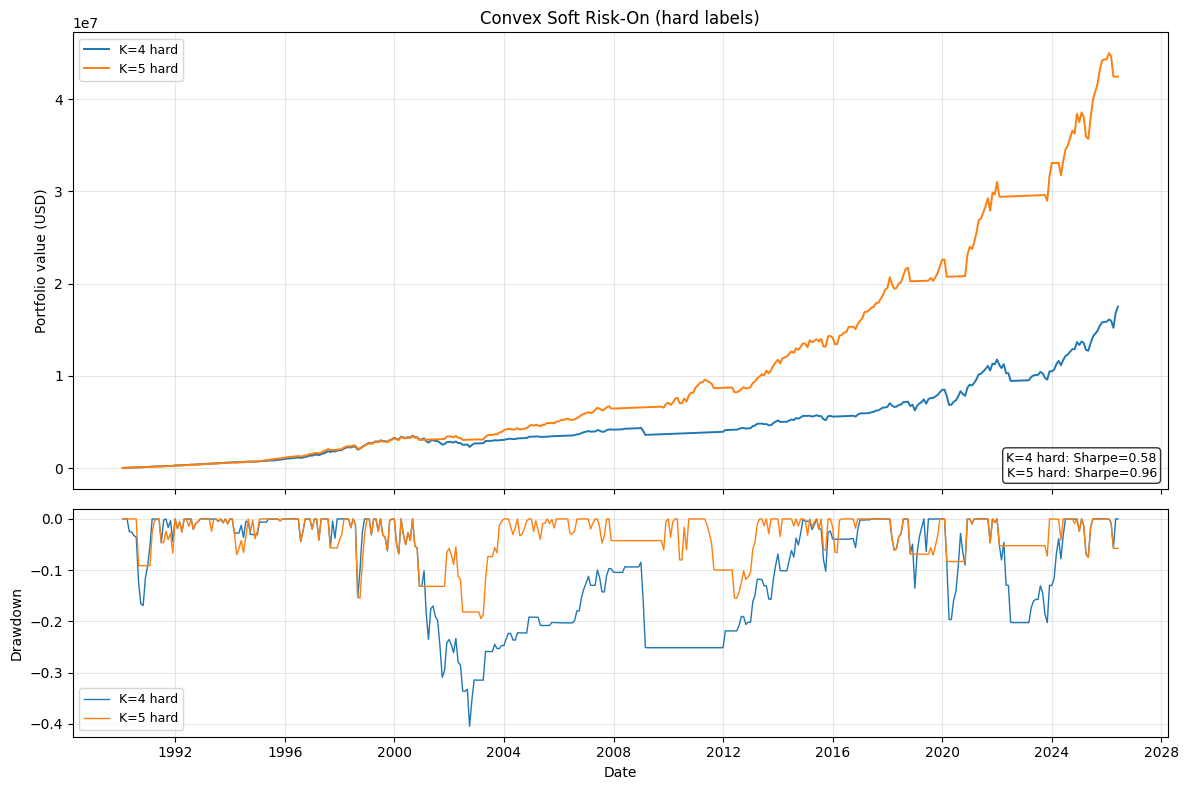

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 hard,437,4370000.0,1.751415e+07,1.314415e+07,4.007815,0.068746,0.118825,0.578543,0.965622,-0.404712,0.169863,0.437071,0.235698,176,11.259166,convex_soft_risk_on,hard
K=5 hard,437,4370000.0,4.245601e+07,3.808601e+07,9.715334,0.102514,0.107240,0.955929,1.797354,-0.194381,0.527387,0.512586,0.082380,39,34.953228,convex_soft_risk_on,hard


In [19]:
run_cell("convex_soft_risk_on", soft=False, title="Convex Soft Risk-On (hard labels)")

          Months  Total_Invested_USD  Final_Portfolio_USD  Profit_USD  Multiple   CAGR  Annual_Vol  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate  Avg_Monthly_Turnover
Label                                                                                                                                                                    
K=4 soft     437           4,370,000           16,438,980  12,068,980    3.7618 0.0662      0.1140  0.5808   0.9672       -0.4016  0.1648    0.6499                0.2022
K=5 soft     437           4,370,000           24,291,963  19,921,963    5.5588 0.0811      0.1023  0.7926   1.3956       -0.3592  0.2258    0.6590                0.1619


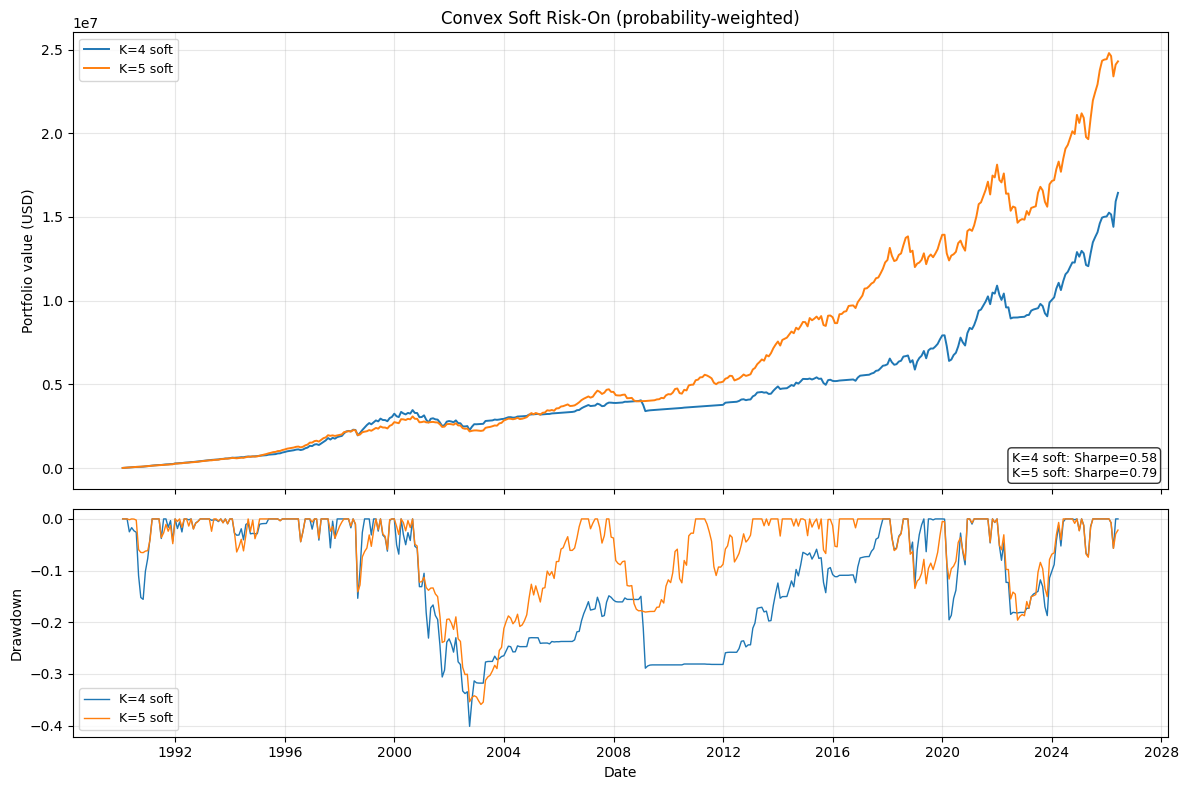

,Months,Total_Invested_USD,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Annual_Vol,Sharpe,Sortino,Max_Drawdown,Calmar,Win_Rate,Avg_Monthly_Turnover,Max_Underwater_Months,Final_NAV_Multiple,Strategy,Mode
Label,,,,,,,,,,,,,,,,,
K=4 soft,437,4370000.0,1.643898e+07,1.206898e+07,3.761780,0.066202,0.113981,0.580814,0.967211,-0.401602,0.164845,0.649886,0.202195,205,10.323377,convex_soft_risk_on,soft
K=5 soft,437,4370000.0,2.429196e+07,1.992196e+07,5.558802,0.081095,0.102309,0.792647,1.395627,-0.359189,0.225772,0.659039,0.161949,73,17.108357,convex_soft_risk_on,soft


In [20]:
run_cell("convex_soft_risk_on", soft=True, title="Convex Soft Risk-On (probability-weighted)")

## Summary — all strategies

In [21]:
summary = pd.concat(ALL_METRICS)
summary.index.name = "Run"
summary = summary.reset_index()

cols = [
    "Run", "Strategy", "Mode", "Final_Portfolio_USD", "Profit_USD", "Multiple",
    "CAGR", "Sharpe", "Sortino", "Max_Drawdown", "Calmar", "Annual_Vol", "Win_Rate",
]
cols = [c for c in cols if c in summary.columns]
display(summary[cols].sort_values(["Strategy", "Mode", "Run"]))

out_path = PROJECT_ROOT / "data" / "outputs" / "strategy_comparison_summary.csv"
summary.to_csv(out_path, index=False)
print(f"Saved {out_path}")

,Run,Strategy,Mode,Final_Portfolio_USD,Profit_USD,Multiple,CAGR,Sharpe,Sortino,Max_Drawdown,Calmar,Annual_Vol,Win_Rate
9,K=4 hard,all_weather,hard,3.015127e+07,2.578127e+07,6.899604,0.095244,0.778780,1.369000,-0.380182,0.250523,0.122299,0.638444
10,K=5 hard,all_weather,hard,4.305277e+07,3.868277e+07,9.851893,0.110182,0.990791,1.866767,-0.248152,0.444012,0.111207,0.656751
11,K=4 soft,all_weather,soft,2.959564e+07,2.522564e+07,6.772457,0.093640,0.798741,1.389827,-0.385960,0.242616,0.117235,0.649886
12,K=5 soft,all_weather,soft,2.043867e+07,1.606867e+07,4.677041,0.080090,0.815519,1.417163,-0.229183,0.349458,0.098207,0.645309
29,K=4 hard,all_weather_defensive,hard,2.320198e+07,1.883198e+07,5.309378,0.084181,0.939725,1.658912,-0.243827,0.345249,0.089580,0.686499
30,K=5 hard,all_weather_defensive,hard,2.709677e+07,2.272677e+07,6.200635,0.091459,1.099829,2.092375,-0.162761,0.561924,0.083158,0.670481
31,K=4 soft,all_weather_defensive,soft,2.291459e+07,1.854459e+07,5.243612,0.083205,0.944580,1.665995,-0.247723,0.335879,0.088087,0.679634
32,K=5 soft,all_weather_defensive,soft,1.879045e+07,1.442045e+07,4.299874,0.075863,0.917241,1.604063,-0.248162,0.305701,0.082708,0.649886
25,K=4 hard,bond_floor_tactical,hard,1.917457e+07,1.480457e+07,4.387773,0.075135,0.848298,1.499080,-0.226543,0.331657,0.088571,0.640732
26,K=5 hard,bond_floor_tactical,hard,3.138464e+07,2.701464e+07,7.181840,0.095826,1.190245,2.356277,-0.174749,0.548361,0.080509,0.668192


Saved /Users/antoinea/Desktop/ADIA Master Thesis/Thesis_ADIA/Master-Thesis-ADIA-Regime-Detection/pmr_paper/data/outputs/strategy_comparison_summary.csv


## Ranking
Rank all runs with simple objective functions and optional drawdown constraints.

In [22]:
import numpy as np

# You can tighten this (e.g. -0.20) to filter high drawdown runs.
MAX_DRAWDOWN_CEILING = -0.30  # keep runs with Max_Drawdown >= ceiling
ONLY_K5 = False

rank_df = summary.copy()

# Ensure numeric types
for c in ["Sharpe", "Max_Drawdown", "CAGR", "Annual_Vol", "Profit_USD", "Final_Portfolio_USD", "Avg_Monthly_Turnover"]:
    if c in rank_df.columns:
        rank_df[c] = pd.to_numeric(rank_df[c], errors="coerce")

# Basic derived scores
if "Max_Drawdown" in rank_df.columns:
    dd = rank_df["Max_Drawdown"].abs()
else:
    dd = np.nan

rank_df["Sharpe_per_DD"] = rank_df["Sharpe"] / dd
rank_df["Return_per_DD"] = rank_df["CAGR"] / dd

# Filters
mask = pd.Series(True, index=rank_df.index)
if "Max_Drawdown" in rank_df.columns:
    mask &= rank_df["Max_Drawdown"].ge(float(MAX_DRAWDOWN_CEILING))
if ONLY_K5 and "Run" in rank_df.columns:
    mask &= rank_df["Run"].astype(str).str.contains("K=5")

rank_df = rank_df.loc[mask].copy()

# Display top runs under different objectives
show_cols = [
    "Run", "Strategy", "Mode",
    "Sharpe", "Sortino", "CAGR", "Annual_Vol",
    "Max_Drawdown", "Calmar",
    "Final_Portfolio_USD", "Profit_USD",
    "Avg_Monthly_Turnover",
    "Sharpe_per_DD", "Return_per_DD",
]
show_cols = [c for c in show_cols if c in rank_df.columns]

print(f"Ranking universe: {len(rank_df)} runs (ceiling={MAX_DRAWDOWN_CEILING}, ONLY_K5={ONLY_K5})")

display(rank_df[show_cols].sort_values(["Sharpe"], ascending=False).head(15))
display(rank_df[show_cols].sort_values(["Sharpe_per_DD"], ascending=False).head(15))
display(rank_df[show_cols].sort_values(["Final_Portfolio_USD"], ascending=False).head(15))

Ranking universe: 19 runs (ceiling=-0.3, ONLY_K5=False)


,Run,Strategy,Mode,Sharpe,Sortino,CAGR,Annual_Vol,Max_Drawdown,Calmar,Final_Portfolio_USD,Profit_USD,Avg_Monthly_Turnover,Sharpe_per_DD,Return_per_DD
26,K=5 hard,bond_floor_tactical,hard,1.190245,2.356277,0.095826,0.080509,-0.174749,0.548361,3.138464e+07,2.701464e+07,0.115332,6.811163,0.548361
30,K=5 hard,all_weather_defensive,hard,1.099829,2.092375,0.091459,0.083158,-0.162761,0.561924,2.709677e+07,2.272677e+07,0.100686,6.757340,0.561924
18,K=5 hard,defensive_safe_haven,hard,1.079311,1.997565,0.096041,0.088984,-0.180575,0.531862,3.132012e+07,2.695012e+07,0.161098,5.977067,0.531862
28,K=5 soft,bond_floor_tactical,soft,1.052843,1.957177,0.083640,0.079442,-0.204025,0.409950,2.336562e+07,1.899562e+07,0.199220,5.160350,0.409950
6,K=5 hard,safe_haven,hard,1.050900,2.000795,0.115656,0.110055,-0.185955,0.621958,5.445019e+07,5.008019e+07,0.164760,5.651355,0.621958
14,K=5 hard,inverse_vol,hard,0.992407,1.861940,0.105991,0.106802,-0.263182,0.402730,4.515931e+07,4.078931e+07,0.061785,3.770796,0.402730
22,K=5 hard,crisis_cap_inverse_vol,hard,0.990799,1.861174,0.102647,0.103600,-0.281762,0.364303,4.148902e+07,3.711902e+07,0.070325,3.516436,0.364303
10,K=5 hard,all_weather,hard,0.990791,1.866767,0.110182,0.111207,-0.248152,0.444012,4.305277e+07,3.868277e+07,0.199085,3.992676,0.444012
2,K=5 hard,risk_on_off,hard,0.955929,1.797354,0.102514,0.107240,-0.194381,0.527387,4.245601e+07,3.808601e+07,0.082380,4.917814,0.527387
34,K=5 hard,convex_soft_risk_on,hard,0.955929,1.797354,0.102514,0.107240,-0.194381,0.527387,4.245601e+07,3.808601e+07,0.082380,4.917814,0.527387


,Run,Strategy,Mode,Sharpe,Sortino,CAGR,Annual_Vol,Max_Drawdown,Calmar,Final_Portfolio_USD,Profit_USD,Avg_Monthly_Turnover,Sharpe_per_DD,Return_per_DD
26,K=5 hard,bond_floor_tactical,hard,1.190245,2.356277,0.095826,0.080509,-0.174749,0.548361,3.138464e+07,2.701464e+07,0.115332,6.811163,0.548361
30,K=5 hard,all_weather_defensive,hard,1.099829,2.092375,0.091459,0.083158,-0.162761,0.561924,2.709677e+07,2.272677e+07,0.100686,6.757340,0.561924
18,K=5 hard,defensive_safe_haven,hard,1.079311,1.997565,0.096041,0.088984,-0.180575,0.531862,3.132012e+07,2.695012e+07,0.161098,5.977067,0.531862
6,K=5 hard,safe_haven,hard,1.050900,2.000795,0.115656,0.110055,-0.185955,0.621958,5.445019e+07,5.008019e+07,0.164760,5.651355,0.621958
28,K=5 soft,bond_floor_tactical,soft,1.052843,1.957177,0.083640,0.079442,-0.204025,0.409950,2.336562e+07,1.899562e+07,0.199220,5.160350,0.409950
2,K=5 hard,risk_on_off,hard,0.955929,1.797354,0.102514,0.107240,-0.194381,0.527387,4.245601e+07,3.808601e+07,0.082380,4.917814,0.527387
34,K=5 hard,convex_soft_risk_on,hard,0.955929,1.797354,0.102514,0.107240,-0.194381,0.527387,4.245601e+07,3.808601e+07,0.082380,4.917814,0.527387
20,K=5 soft,defensive_safe_haven,soft,0.952892,1.651456,0.081345,0.085366,-0.206872,0.393213,2.219889e+07,1.782889e+07,0.368474,4.606184,0.393213
10,K=5 hard,all_weather,hard,0.990791,1.866767,0.110182,0.111207,-0.248152,0.444012,4.305277e+07,3.868277e+07,0.199085,3.992676,0.444012
29,K=4 hard,all_weather_defensive,hard,0.939725,1.658912,0.084181,0.089580,-0.243827,0.345249,2.320198e+07,1.883198e+07,0.267735,3.854070,0.345249


,Run,Strategy,Mode,Sharpe,Sortino,CAGR,Annual_Vol,Max_Drawdown,Calmar,Final_Portfolio_USD,Profit_USD,Avg_Monthly_Turnover,Sharpe_per_DD,Return_per_DD
6,K=5 hard,safe_haven,hard,1.050900,2.000795,0.115656,0.110055,-0.185955,0.621958,5.445019e+07,5.008019e+07,0.164760,5.651355,0.621958
14,K=5 hard,inverse_vol,hard,0.992407,1.861940,0.105991,0.106802,-0.263182,0.402730,4.515931e+07,4.078931e+07,0.061785,3.770796,0.402730
10,K=5 hard,all_weather,hard,0.990791,1.866767,0.110182,0.111207,-0.248152,0.444012,4.305277e+07,3.868277e+07,0.199085,3.992676,0.444012
2,K=5 hard,risk_on_off,hard,0.955929,1.797354,0.102514,0.107240,-0.194381,0.527387,4.245601e+07,3.808601e+07,0.082380,4.917814,0.527387
34,K=5 hard,convex_soft_risk_on,hard,0.955929,1.797354,0.102514,0.107240,-0.194381,0.527387,4.245601e+07,3.808601e+07,0.082380,4.917814,0.527387
22,K=5 hard,crisis_cap_inverse_vol,hard,0.990799,1.861174,0.102647,0.103600,-0.281762,0.364303,4.148902e+07,3.711902e+07,0.070325,3.516436,0.364303
26,K=5 hard,bond_floor_tactical,hard,1.190245,2.356277,0.095826,0.080509,-0.174749,0.548361,3.138464e+07,2.701464e+07,0.115332,6.811163,0.548361
18,K=5 hard,defensive_safe_haven,hard,1.079311,1.997565,0.096041,0.088984,-0.180575,0.531862,3.132012e+07,2.695012e+07,0.161098,5.977067,0.531862
30,K=5 hard,all_weather_defensive,hard,1.099829,2.092375,0.091459,0.083158,-0.162761,0.561924,2.709677e+07,2.272677e+07,0.100686,6.757340,0.561924
28,K=5 soft,bond_floor_tactical,soft,1.052843,1.957177,0.083640,0.079442,-0.204025,0.409950,2.336562e+07,1.899562e+07,0.199220,5.160350,0.409950
